In [2]:
import pandas as pd
df = pd.read_csv("data/orders.csv")
df.head()

,order_id,customer,region,product,category,price,quantity,order_date
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10
1,1002,Piotr,Warsaw,Mouse,Electronics,80,2,2026-01-11
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13
4,1005,Magda,Warsaw,Keyboard,Electronics,150,1,2026-01-14


In [3]:
#task 1
df['order_value'] = df['price'] * df['quantity']
df.head(5)

,order_id,customer,region,product,category,price,quantity,order_date,order_value
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500
1,1002,Piotr,Warsaw,Mouse,Electronics,80,2,2026-01-11,160
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12,900
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13,1600
4,1005,Magda,Warsaw,Keyboard,Electronics,150,1,2026-01-14,150


In [4]:
#task2
top_region = df.groupby('region')['price'].sum()
top_region

region
Gdansk    1550
Krakow    6095
Warsaw    4930
Name: price, dtype: int64

In [5]:
#task 3
top_category_income = df.groupby('category')['order_value'].sum()
top_category_income

category
Electronics    11285
Furniture       4890
Name: order_value, dtype: int64

In [6]:
#task 4
mean_of_order = df['order_value'].mean()
print(mean_of_order)

1347.9166666666667


In [7]:
#task 5
best_client_revenue = df.groupby('customer')['order_value'].sum().sort_values(ascending = False)
print(best_client_revenue)

customer
Marek     3600
Anna      3500
Bartek    2400
Tomek     1600
Julia     1100
Kamil      950
Kasia      900
Adam       840
Ola        600
Ewa        375
Piotr      160
Magda      150
Name: order_value, dtype: int64


In [8]:
#dzień 2
#task 1
mean_by_region = df.groupby('region')['order_value'].mean()
print(mean_by_region)

region
Gdansk    1050.0
Krakow    1603.0
Warsaw    1252.5
Name: order_value, dtype: float64


In [9]:
print(df.groupby('region').size())

region
Gdansk    3
Krakow    5
Warsaw    4
dtype: int64


In [10]:
#task 2
most_sold_product = df['product'].value_counts()
most_sold_product

product
Laptop      2
Mouse       2
Desk        2
Chair       2
Monitor     2
Keyboard    1
Lamp        1
Name: count, dtype: int64

In [11]:
#task 3
product_values = df.groupby('product')['order_value'].sum().sort_values(ascending = False)
product_values

product
Laptop      7100
Monitor     3500
Chair       2440
Desk        1850
Lamp         600
Mouse        535
Keyboard     150
Name: order_value, dtype: int64

In [12]:
#task 4
worst_revenue_region = df.groupby('region')['order_value'].sum().idxmin()
worst_revenue_region

'Gdansk'

In [13]:
#task 5 only high revenue
expensive_orders = df[df['order_value'] > 2000]
expensive_orders.head()

,order_id,customer,region,product,category,price,quantity,order_date,order_value
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500
5,1006,Bartek,Krakow,Monitor,Electronics,1200,2,2026-01-15,2400
7,1008,Marek,Warsaw,Laptop,Electronics,3600,1,2026-01-17,3600


In [14]:
#task 6
exp_total_revenue = expensive_orders['order_value'].sum()
all_total_revenue = df['order_value'].sum()

print(exp_total_revenue)
print(all_total_revenue)
print(f"Udział wysokich zamowien w porownaniu do wszystkich to {(exp_total_revenue / all_total_revenue * 100).round(2)} %")

9500
16175
Udział wysokich zamowien w porownaniu do wszystkich to 58.73 %


In [21]:
#Niedziela day last prep
#task1
df.shape

(12, 9)

In [18]:
df.columns

Index(['order_id', 'customer', 'region', 'product', 'category', 'price',
       'quantity', 'order_date', 'order_value'],
      dtype='object')

In [19]:
df.head()

,order_id,customer,region,product,category,price,quantity,order_date,order_value
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500
1,1002,Piotr,Warsaw,Mouse,Electronics,80,2,2026-01-11,160
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12,900
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13,1600
4,1005,Magda,Warsaw,Keyboard,Electronics,150,1,2026-01-14,150


In [20]:
df.describe()

,order_id,price,quantity,order_value
count,12.000000,12.000000,12.0000,12.000000
mean,1006.500000,1047.916667,2.0000,1347.916667
std,3.605551,1236.044752,1.3484,1202.432116
min,1001.000000,75.000000,1.0000,150.000000
25%,1003.750000,187.500000,1.0000,543.750000
50%,1006.500000,660.000000,1.5000,925.000000
75%,1009.250000,1125.000000,2.2500,1800.000000
max,1012.000000,3600.000000,5.0000,3600.000000


In [36]:
df['discount'] = 0
df.loc[df['order_value'] > 2000, 'discount'] = df['order_value'] * 0.1 
df.head()
df['final_price'] = df['order_value'] - df['discount']
df.head()

,order_id,customer,region,product,category,price,quantity,order_date,order_value,discount,final_price
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500,350,3150
1,1002,Piotr,Warsaw,Mouse,Electronics,80,2,2026-01-11,160,0,160
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12,900,0,900
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13,1600,0,1600
4,1005,Magda,Warsaw,Keyboard,Electronics,150,1,2026-01-14,150,0,150


In [41]:
df['segment'] = "standard"
df.loc[df['order_value'] > 2000, 'segment'] = 'premium'
df.head()

,order_id,customer,region,product,category,price,quantity,order_date,order_value,discount,final_price,segment
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500,350,3150,premium
1,1002,Piotr,Warsaw,Mouse,Electronics,80,2,2026-01-11,160,0,160,standard
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12,900,0,900,standard
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13,1600,0,1600,standard
4,1005,Magda,Warsaw,Keyboard,Electronics,150,1,2026-01-14,150,0,150,standard


In [54]:
sorted_final_price = df.sort_values('final_price', ascending = False)
sorted_final_price.head(3)

,order_id,customer,region,product,category,price,quantity,order_date,order_value,discount,final_price,segment
7,1008,Marek,Warsaw,Laptop,Electronics,3600,1,2026-01-17,3600,360,3240,premium
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500,350,3150,premium
5,1006,Bartek,Krakow,Monitor,Electronics,1200,2,2026-01-15,2400,240,2160,premium


In [65]:
total_standard = df.groupby('segment')['final_price'].sum()
total_standard
print(f"Wartosc zamowien standard to {total_standard['standard']} a zamowien premium to {total_standard['premium']}")

Wartosc zamowien standard to 6675 a zamowien premium to 8550


In [69]:
part_premium_of_revenue = ((total_standard['premium'] / df['final_price'].sum()) * 100).round(3)
print(f"{part_premium_of_revenue} %")

56.158 %


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     12 non-null     int64 
 1   customer     12 non-null     object
 2   region       12 non-null     object
 3   product      12 non-null     object
 4   category     12 non-null     object
 5   price        12 non-null     int64 
 6   quantity     12 non-null     int64 
 7   order_date   12 non-null     object
 8   order_value  12 non-null     int64 
 9   discount     12 non-null     int64 
 10  final_price  12 non-null     int64 
 11  segment      12 non-null     object
dtypes: int64(6), object(6)
memory usage: 1.3+ KB


In [72]:
df.isna().sum()

order_id       0
customer       0
region         0
product        0
category       0
price          0
quantity       0
order_date     0
order_value    0
discount       0
final_price    0
segment        0
dtype: int64

In [77]:
df['VAT'] = df['final_price'] * 0.23
df['BRUTTO_PRICE'] = df['final_price'] + df['VAT']
df.head()

,order_id,customer,region,product,category,price,quantity,order_date,order_value,discount,final_price,segment,VAT,BRUTTO_PRICE
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500,350,3150,premium,724.5,3874.5
1,1002,Piotr,Warsaw,Mouse,Electronics,80,2,2026-01-11,160,0,160,standard,36.8,196.8
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12,900,0,900,standard,207.0,1107.0
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13,1600,0,1600,standard,368.0,1968.0
4,1005,Magda,Warsaw,Keyboard,Electronics,150,1,2026-01-14,150,0,150,standard,34.5,184.5


In [78]:
df.sort_values('VAT', ascending = False)


,order_id,customer,region,product,category,price,quantity,order_date,order_value,discount,final_price,segment,VAT,BRUTTO_PRICE
7,1008,Marek,Warsaw,Laptop,Electronics,3600,1,2026-01-17,3600,360,3240,premium,745.20,3985.20
0,1001,Anna,Krakow,Laptop,Electronics,3500,1,2026-01-10,3500,350,3150,premium,724.50,3874.50
5,1006,Bartek,Krakow,Monitor,Electronics,1200,2,2026-01-15,2400,240,2160,premium,496.80,2656.80
3,1004,Tomek,Gdansk,Chair,Furniture,400,4,2026-01-13,1600,0,1600,standard,368.00,1968.00
10,1011,Julia,Warsaw,Monitor,Electronics,1100,1,2026-01-20,1100,0,1100,standard,253.00,1353.00
9,1010,Kamil,Gdansk,Desk,Furniture,950,1,2026-01-19,950,0,950,standard,218.50,1168.50
2,1003,Kasia,Krakow,Desk,Furniture,900,1,2026-01-12,900,0,900,standard,207.00,1107.00
11,1012,Adam,Krakow,Chair,Furniture,420,2,2026-01-21,840,0,840,standard,193.20,1033.20
6,1007,Ola,Gdansk,Lamp,Furniture,200,3,2026-01-16,600,0,600,standard,138.00,738.00
8,1009,Ewa,Krakow,Mouse,Electronics,75,5,2026-01-18,375,0,375,standard,86.25,461.25


<Axes: xlabel='region'>

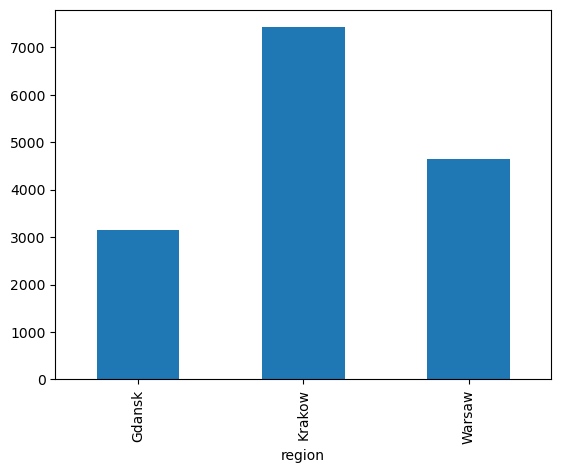

In [81]:
revenue_region = df.groupby('region')['final_price'].sum()
revenue_region.plot(kind = 'bar')

In [83]:
df.tail(5)

,order_id,customer,region,product,category,price,quantity,order_date,order_value,discount,final_price,segment,VAT,BRUTTO_PRICE
7,1008,Marek,Warsaw,Laptop,Electronics,3600,1,2026-01-17,3600,360,3240,premium,745.20,3985.20
8,1009,Ewa,Krakow,Mouse,Electronics,75,5,2026-01-18,375,0,375,standard,86.25,461.25
9,1010,Kamil,Gdansk,Desk,Furniture,950,1,2026-01-19,950,0,950,standard,218.50,1168.50
10,1011,Julia,Warsaw,Monitor,Electronics,1100,1,2026-01-20,1100,0,1100,standard,253.00,1353.00
11,1012,Adam,Krakow,Chair,Furniture,420,2,2026-01-21,840,0,840,standard,193.20,1033.20
